# uv1 shape-parameter scan -> new PDF data

Generates new PDF data by varying the last four parameters `[a, b, c, d]` of
the five-parameter input shape `uv1 = [N, a, b, c, d]`, using `qcdlibnb` and
`config/qcd.yaml`. `N` (the normalization) is recomputed automatically from
the valence sum rule every time parameters are updated -- see the note in
Section 2.

Verified directly against the `qcdlibnb`/`qcdlib` source in
`FemtoMind/JAM2Pythia`:
- YAML key path: `qcd.pdf.parameters.uv1`, a 5-element `[N, a, b, c, d]` list.
- Baseline `uv1` in `config/qcd.yaml`: `[0.32, -0.71, 3.48, 1.34, 23.3]`.
- Current parameters live on `pdf.params["uv1"]` after construction.


In [13]:
import os
from pathlib import Path

REPO_ROOT = Path("/work/JAM/rathman/JAM2Pythia")
CONFIG_PATH = REPO_ROOT / "config" / "qcd.yaml"

import sys
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SCRATCH_ROOT = Path("uv1_data")
OUTPUT_ROOT = SCRATCH_ROOT / "jam2pythia_uv1_scan" / "lhapdf"
DATA_OUTPUT = SCRATCH_ROOT / "jam2pythia_uv1_scan" / "pickles"

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT.mkdir(parents=True, exist_ok=True)

assert CONFIG_PATH.exists(), f"config not found at {CONFIG_PATH} -- check JAM2PYTHIA_ROOT"

print(f"REPO_ROOT   = {REPO_ROOT}")
print(f"CONFIG_PATH = {CONFIG_PATH}")
print(f"OUTPUT_ROOT = {OUTPUT_ROOT}")
print(f"DATA_OUTPUT = {DATA_OUTPUT}")

REPO_ROOT   = /work/JAM/rathman/JAM2Pythia
CONFIG_PATH = /work/JAM/rathman/JAM2Pythia/config/qcd.yaml
OUTPUT_ROOT = uv1_data/jam2pythia_uv1_scan/lhapdf
DATA_OUTPUT = uv1_data/jam2pythia_uv1_scan/pickles


## 0b. Perturbative order

`qcd.order` (`LO` / `NLO` / `NNLO`) is a single top-level YAML field
consumed by *both* `AlphaSConfig.from_yaml` and `DglapConfig.from_yaml`
(`qcdlib/alphaS.py`, `qcdlib/dglap.py`). `DglapEvolution.__init__` requires
the two to agree (`AlphaS and DGLAP perturbative orders must match`), so
order is never something you vary per-replica within one run -- it's a
property of the whole scan.

`UnpolarizedPDF.from_yaml` only exposes an override for `alpha_s_mz`, not
for order, so getting LO output means `config/qcd.yaml` itself needs
`order: LO`. **Edit that field directly in `config/qcd.yaml` before running
this notebook** (rather than overriding it in-notebook) if you only need one
order per run -- simpler, and there's only one file to keep in sync.

To avoid the label ever drifting out of sync with what's actually in the
YAML (e.g. editing the file but forgetting to update a hardcoded string
elsewhere), the cell below reads the order back off the constructed `pdf`
object itself rather than hardcoding it, and that value is what gets used
for `set_name`/manifest labeling later.


## 1. Inspect the baseline `uv1` parameters in `config/qcd.yaml`

In [14]:
import yaml

with open(CONFIG_PATH) as f:
    qcd_config = yaml.safe_load(f)

# Confirmed key path (config/qcd.yaml): qcd.pdf.parameters.<name>, each a
# 5-element [N, a, b, c, d] list. See qcdlib/pdf.py:PDFConfig.from_yaml.
baseline_uv1 = list(qcd_config["qcd"]["pdf"]["parameters"]["uv1"])
assert len(baseline_uv1) == 5, "expected [N, a, b, c, d]"

N_uv1 = baseline_uv1[0]
abcd_baseline = baseline_uv1[1:]
print("baseline uv1 [N, a, b, c, d] =", baseline_uv1)


baseline uv1 [N, a, b, c, d] = [0.32, -0.71, 3.48, 1.34, 23.3]


## 2. Build the baseline PDF and confirm the update-parameters API

In [15]:
import numpy as np
from qcdlibnb.pdf import UnpolarizedPDF

# from_yaml wires together the Numba-backed Mellin, AlphaS, and DGLAP pieces
# (qcdlibnb/mellin.py, alphaS.py, kernels.py, dglap.py) from the same YAML,
# then hands them to the shared qcdlib.pdf.UnpolarizedPDF implementation.
pdf = UnpolarizedPDF.from_yaml(str(CONFIG_PATH))

# Read order back off the object rather than hardcoding it, so labels below
# can never drift out of sync with what's actually in config/qcd.yaml.
ORDER = pdf.alpha_s.order_name  # "LO" | "NLO" | "NNLO" (qcdlib/alphaS.py)

# Confirmed: current input-scale shape parameters live in pdf.params, a dict
# of {flavor_name: np.array([N, a, b, c, d])} (qcdlib/pdf.py:__init__).
print("order in use:", ORDER)
print("pdf.params['uv1'] =", pdf.params["uv1"])
print("pdf.PAR =", pdf.PAR)   # ["N", "a", "b", "c", "d"]


order in use: LO
pdf.params['uv1'] = [ 0.31129074 -0.71        3.48        1.34       23.3       ]
pdf.PAR = ['N', 'a', 'b', 'c', 'd']


## 3. Define the scan over the last four `uv1` parameters

`N` is held fixed here; if the sum rules are re-applied downstream (as in
`export_set`), the normalization is recomputed anyway, so fixing `N` at the
baseline value is a safe starting point rather than a hard constraint.

Sampling is **flat (uniform)** over fixed, physically motivated absolute
bounds for `a, b, c, d` -- not a Gaussian ball around the baseline -- so the
generated data set covers the parameter space evenly rather than clustering
near the current best-fit values. Draws are placed with **Latin Hypercube
Sampling (LHS)** over the 4D `(a, b, c, d)` box, which space-fills much more
evenly than independent per-parameter uniform draws for the same sample
count (fewer clumps/gaps, especially at small batch sizes).

Bounds (fixed, not relative to baseline):

| param | role                                | bounds     |
|-------|-------------------------------------|------------|
| `a`   | small-`x` power                     | `[-1, 0]`  |
| `b`   | large-`x` power, `(1-x)^b`           | `(0, 10]`  |
| `c`   | subleading shape term               | `[-50, 50]`|
| `d`   | subleading shape term               | `[-50, 50]`|

`b` is bounded strictly above 0 (a physical requirement: the valence PDF
must vanish as `x -> 1`), and the upper bound of `10` is a **CHANGE**-tagged
default -- baseline `b` is 3.48, so this leaves headroom on both sides
without drifting into implausibly steep large-`x` falloff. Adjust freely.

This box is not guaranteed to produce a physical (non-negative) `xf(x, Q^2)`
for every draw -- see the note below and the generate/evolve/reject loop in
Section 4, which is what actually enforces positivity.


In [16]:
from scipy.stats import qmc

# CHANGE: fixed absolute bounds for [a, b, c, d]. b's lower bound is held
# strictly > 0 (physical requirement: valence PDF -> 0 as x -> 1); its upper
# bound of 10 is a placeholder default, adjust as needed.
PARAM_BOUNDS = {
    "a": (-1.0, 0.0),
    "b": (1e-3, 10.0),   # strictly positive; 1e-3 stands in for "> 0"
    "c": (-50.0, 50.0),
    "d": (-50.0, 50.0),
}
LHS_SEED = 42  # base seed; each batch below uses LHS_SEED + round_index, so
                # every round is still an independent, reproducible LHS draw


def make_uv1_variations(N, bounds=PARAM_BOUNDS, n_samples=150, seed=LHS_SEED):
    """Latin-Hypercube-sample (a, b, c, d) uniformly over `bounds`, returning
    an (n_samples, 5) array of uv1 = [N, a, b, c, d] with N held fixed."""
    lows = np.array([bounds[k][0] for k in ("a", "b", "c", "d")])
    highs = np.array([bounds[k][1] for k in ("a", "b", "c", "d")])

    sampler = qmc.LatinHypercube(d=4, seed=seed)
    unit_samples = sampler.random(n=n_samples)          # in [0, 1)^4
    abcd = qmc.scale(unit_samples, lows, highs)          # scaled into bounds

    N_col = np.full((n_samples, 1), N)
    return np.hstack([N_col, abcd])


**Physicality check.** The `[-50, 50]` range on `c, d` is wide relative to
the baseline (`1.34, 23.3`), and the Beta-function-style ansatz used by
`qcdlib.pdf.UnpolarizedPDF` does not forbid negative `xf(x)` for arbitrary
`(a, b, c, d)`. `UnpolarizedPDF.check_positivity()` sums the negative-density
violations across flavors on a default `x` grid; a nonzero score means that
draw produced an unphysical PDF and should be rejected.

**Tolerance is empirically calibrated, not `0`.** Running the unperturbed
baseline through `check_positivity()` gives `~5.9e-4`, not `0` -- this floor
comes from the *unperturbed* `g, d, s, ub, db, sb` flavors (they aren't part
of this `uv1`-only scan), so it's expected and not a sign of a bad draw.
Checked against 100 actual LHS draws at these bounds, scores split cleanly:
physical draws sit at that same ~5.9e-4 floor, while genuinely unphysical
draws jump by orders of magnitude (into the thousands-to-millions range).
`tol=1e-2` sits safely in the gap between the two. Using `tol=1e-6` (i.e.
requiring the numerical floor itself to be zero) would reject every draw,
including the physical ones.

**This is only a cheap pre-screen, not the real gate.** `check_positivity()`
evaluates at Q0^2 (the input boundary condition), before evolution. A draw
can pass this check and still develop negative `xf` once evolved out to
other `Q^2` -- DGLAP evolution reshapes the distribution nonlinearly, it
doesn't just rescale it. The loop in Section 4 below uses this Q0^2 check
only to cheaply discard obviously-bad draws before paying for a full
evolution, then applies a second, stricter check against the fully evolved
`(Q^2, x)` grid, which is what actually decides whether a draw enters the
dataset.


## 4. Generate-evolve-reject loop: sample until `N_TARGET` physical templates are collected

Rather than drawing one fixed-size LHS batch and post-hoc dropping whatever
turns out unphysical (which leaves an unpredictable final count and throws
away draws you already paid to evolve), this draws LHS batches repeatedly
and keeps only the ones that survive **both** positivity checks, stopping
once `N_TARGET` physical templates have been collected:

1. Draw a batch of `BATCH_SIZE` candidates via LHS.
2. For each candidate: cheap Q0^2 pre-screen (`check_positivity()`) --
   reject obviously unphysical draws before evolving.
3. For survivors: evolve `xf_uv(x, Q^2)` across the full `X_GRID` x
   `Q2_GRID` and reject if it goes negative anywhere on that grid.
4. Accept the rest into the dataset. If `N_TARGET` isn't reached, draw
   another batch (new LHS seed) and repeat, up to `MAX_ROUNDS`.

Each batch is still LHS internally (even coverage within that batch); across
batches this is rejection sampling with LHS proposals rather than
independent uniform ones. `BATCH_SIZE` should oversample relative to
`N_TARGET` since attrition at these bounds is roughly 25-75% depending on
how much of it survives the evolved-grid check (see Section 9 note above).

Data is built directly into dense NumPy arrays (`(n_var, n_q2, n_x)`) rather
than a list of per-curve dicts, since that's what a PINN dataloader actually
wants -- no unpacking, no redundant storage of the shared `x`/`Q^2` grids,
and it maps straight onto the `(xf_uv(x, Q0^2), ln(Q^2))` -> evolved-PDF
input/output shape from your DeepONet setup.

Also note: this pulls the `"uv"` external flavor (pure u-valence), not
`"u"` -- `qcdlib/pdf.py` distinguishes them (`"u"` mixes in sea
contributions via `(up+um)/2`), and `"uv"` is the one that matches `xf_uv`.


In [17]:
X_GRID = 10**np.linspace(-4, np.log10(1), 200)
Q2_GRID = [1.6129, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000]

n_q2 = len(Q2_GRID)
n_x = len(X_GRID)


In [18]:
# Generate-evolve-reject loop (see Section 4 markdown above).

N_TARGET = 100          # CHANGE: number of physical templates wanted in the final dataset
BATCH_SIZE = 1000        # draws per round; oversample 
MAX_ROUNDS = 50         # safety cap: fail loudly rather than loop forever on a miscalibrated bound space
POSITIVITY_TOL = 1e-2   # Q0^2 pre-screen tolerance; floor is ~5.9e-4 on this config (see markdown above)
EVOLVED_POSITIVITY_TOL = 0.0   # strict "never negative anywhere on the (Q^2, x) grid" cut

accepted_params = []
accepted_xu = []
n_drawn = 0
n_q0_rejected = 0
n_evolved_rejected = 0
round_idx = 0

while len(accepted_params) < N_TARGET and round_idx < MAX_ROUNDS:
    batch = make_uv1_variations(N_uv1, PARAM_BOUNDS, BATCH_SIZE, seed=LHS_SEED + round_idx)

    for row in batch:
        if len(accepted_params) >= N_TARGET:
            break  # target met -- no need to evolve the rest of this batch
        n_drawn += 1

        pdf.update_parameters(row.reshape(1, 5), flavors=["uv1"])

        # Cheap pre-screen at Q0^2, before paying for a full evolution.
        q0_score = float(pdf.check_positivity().sum())
        if q0_score > POSITIVITY_TOL:
            n_q0_rejected += 1
            continue

        # Passed the cheap screen -- evolve across the full (Q^2, x) grid and
        # gate acceptance on that, since Q0^2 alone doesn't guarantee it.
        curve = np.zeros((n_q2, n_x))
        for j, q2 in enumerate(Q2_GRID):
            curve[j, :] = np.asarray(pdf.get_xf(x=X_GRID, q2=q2, flavor="uv"))

        if curve.min() < EVOLVED_POSITIVITY_TOL:
            n_evolved_rejected += 1
            continue

        accepted_params.append(row)
        accepted_xu.append(curve)

    round_idx += 1
    print(f"round {round_idx}: {len(accepted_params)}/{N_TARGET} accepted "
          f"({n_drawn} drawn, {n_q0_rejected} rejected at Q0^2, "
          f"{n_evolved_rejected} rejected after evolution)")

if len(accepted_params) < N_TARGET:
    print(
        f"WARNING: only {len(accepted_params)}/{N_TARGET} physical templates found "
        f"after {round_idx} rounds ({n_drawn} total draws, MAX_ROUNDS={MAX_ROUNDS}). "
        "Raise MAX_ROUNDS/BATCH_SIZE, or PARAM_BOUNDS is too wide for this target -- "
        "see the per-round attrition breakdown above."
    )

uv1_variations = np.array(accepted_params)
xu_grid = np.array(accepted_xu)
n_var = len(uv1_variations)

print(f"\nfinal: {n_var} physical templates from {n_drawn} draws across {round_idx} round(s) "
      f"({n_var / n_drawn:.1%} acceptance rate)")
print(f"uv1_variations shape: {uv1_variations.shape}, xu_grid shape: {xu_grid.shape}")


round 1: 100/100 accepted (775 drawn, 227 rejected at Q0^2, 448 rejected after evolution)

final: 100 physical templates from 775 draws across 1 round(s) (12.9% acceptance rate)
uv1_variations shape: (100, 5), xu_grid shape: (100, 32, 200)


## 5. (Optional) Export each variation as an LHAPDF grid

Use this if downstream steps (e.g. `mceg`/PYTHIA) need real LHAPDF sets rather
than in-memory arrays. `export_set` builds its own `UnpolarizedPDF` from
`config_path` and forwards `parameters`/`flavors` straight to
`update_parameters`, so this does not depend on the `pdf` object built above.

**Confirmed from `qcdlibnb/export_lhapdf.py`: the `.info` file records
`OrderQCD`/`AlphaS_OrderQCD` automatically** (pulled from
`pdf.alpha_s.config.order`), so the perturbative order of each exported set
*is* self-documenting. **It does NOT record the `uv1` shape parameters**,
though, so the manifest cell below still writes those out separately, keyed
by `set_name`.


In [19]:
from qcdlibnb.export_lhapdf import export_set
import json

EXPORT_LHAPDF = True  # flip to True to actually write grids

exported_sets = []
manifest = {}
if EXPORT_LHAPDF:
    for i, uv1_row in enumerate(uv1_variations):
        set_name = f"uv1_scan_{ORDER}_{i:04d}"
        export_set(
            config_path=str(CONFIG_PATH),  # order comes from config/qcd.yaml as edited
            output_root=str(OUTPUT_ROOT),
            set_name=set_name,
            parameters=uv1_row.reshape(1, 5),
            flavors=["uv1"],
            force=True,
        )
        exported_sets.append(set_name)
        manifest[set_name] = {"uv1": uv1_row.tolist(), "order": ORDER}

    manifest_path = OUTPUT_ROOT / f"uv1_scan_manifest_{ORDER.lower()}.json"
    with open(manifest_path, "w") as f:
        json.dump(manifest, f, indent=2)
    print(exported_sets)
    print(f"wrote {manifest_path}")


['uv1_scan_LO_0000', 'uv1_scan_LO_0001', 'uv1_scan_LO_0002', 'uv1_scan_LO_0003', 'uv1_scan_LO_0004', 'uv1_scan_LO_0005', 'uv1_scan_LO_0006', 'uv1_scan_LO_0007', 'uv1_scan_LO_0008', 'uv1_scan_LO_0009', 'uv1_scan_LO_0010', 'uv1_scan_LO_0011', 'uv1_scan_LO_0012', 'uv1_scan_LO_0013', 'uv1_scan_LO_0014', 'uv1_scan_LO_0015', 'uv1_scan_LO_0016', 'uv1_scan_LO_0017', 'uv1_scan_LO_0018', 'uv1_scan_LO_0019', 'uv1_scan_LO_0020', 'uv1_scan_LO_0021', 'uv1_scan_LO_0022', 'uv1_scan_LO_0023', 'uv1_scan_LO_0024', 'uv1_scan_LO_0025', 'uv1_scan_LO_0026', 'uv1_scan_LO_0027', 'uv1_scan_LO_0028', 'uv1_scan_LO_0029', 'uv1_scan_LO_0030', 'uv1_scan_LO_0031', 'uv1_scan_LO_0032', 'uv1_scan_LO_0033', 'uv1_scan_LO_0034', 'uv1_scan_LO_0035', 'uv1_scan_LO_0036', 'uv1_scan_LO_0037', 'uv1_scan_LO_0038', 'uv1_scan_LO_0039', 'uv1_scan_LO_0040', 'uv1_scan_LO_0041', 'uv1_scan_LO_0042', 'uv1_scan_LO_0043', 'uv1_scan_LO_0044', 'uv1_scan_LO_0045', 'uv1_scan_LO_0046', 'uv1_scan_LO_0047', 'uv1_scan_LO_0048', 'uv1_scan_LO_0049',

## 6. Save the generated data and plot a sanity check

The pickle below is self-describing: it carries the sampling bounds, LHS
seed, order, and config path alongside the actual data, so the run doesn't
depend on this notebook's current state to be interpretable later. The
baseline `uv1` fit values are deliberately **not** included here -- the flat
LHS scan is defined entirely by `PARAM_BOUNDS` and doesn't sample around
`baseline_uv1`, so that value is an arbitrary reference point from whatever
happened to be in `config/qcd.yaml`, not a property of this scan.


In [20]:
import pickle
from datetime import datetime, timezone

metadata = {
    "order": ORDER,
    "param_bounds": PARAM_BOUNDS,
    "n_target": N_TARGET,
    "n_samples_physical": n_var,
    "n_draws_total": n_drawn,
    "n_rounds": round_idx,
    "batch_size": BATCH_SIZE,
    "positivity_tol_q0": POSITIVITY_TOL,
    "positivity_tol_evolved_grid": EVOLVED_POSITIVITY_TOL,
    "lhs_seed": LHS_SEED,
    "config_path": str(CONFIG_PATH),
    "flavor": "uv",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
}

dataset = {
    "metadata": metadata,
    "uv1_variations": uv1_variations,   # (n_var, 5) -> [N, a, b, c, d]
    "x_grid": X_GRID,                    # (n_x,)      -- shared, stored once
    "q2_grid": np.asarray(Q2_GRID),      # (n_q2,)     -- shared, stored once
    "xu": xu_grid,                       # (n_var, n_q2, n_x) -- xf_uv(x, Q^2)
}

with open(DATA_OUTPUT / "uv1_scan_results.pkl", "wb") as f:
    pickle.dump(dataset, f)

print(f"wrote {DATA_OUTPUT / 'uv1_scan_results.pkl'}")
print({k: (v.shape if hasattr(v, 'shape') else v) for k, v in dataset.items() if k != "metadata"})


wrote uv1_data/jam2pythia_uv1_scan/pickles/uv1_scan_results.pkl
{'uv1_variations': (100, 5), 'x_grid': (200,), 'q2_grid': (32,), 'xu': (100, 32, 200)}


**Loading for training:** `uv1_variations[i]` are the shape params for
sample `i`; `xu[i, j, :]` is `xf_uv(x_grid, q2_grid[j])` for that sample.
Broadcasting `uv1_variations` against `xu` (e.g. tiling each row across
`n_q2`) gives you conditioning inputs lined up with targets without any
per-row unpacking:

```python
with open(DATA_OUTPUT / "uv1_scan_results.pkl", "rb") as f:
    d = pickle.load(f)

# flatten to one row per (variation, Q^2) pair, if that's what the
# DeepONet-style loader expects
n_var, n_q2, n_x = d["xu"].shape
uv1_flat = np.repeat(d["uv1_variations"], n_q2, axis=0)         # (n_var*n_q2, 5)
q2_flat = np.tile(d["q2_grid"], n_var)                           # (n_var*n_q2,)
xu_flat = d["xu"].reshape(n_var * n_q2, n_x)                     # (n_var*n_q2, n_x)
```


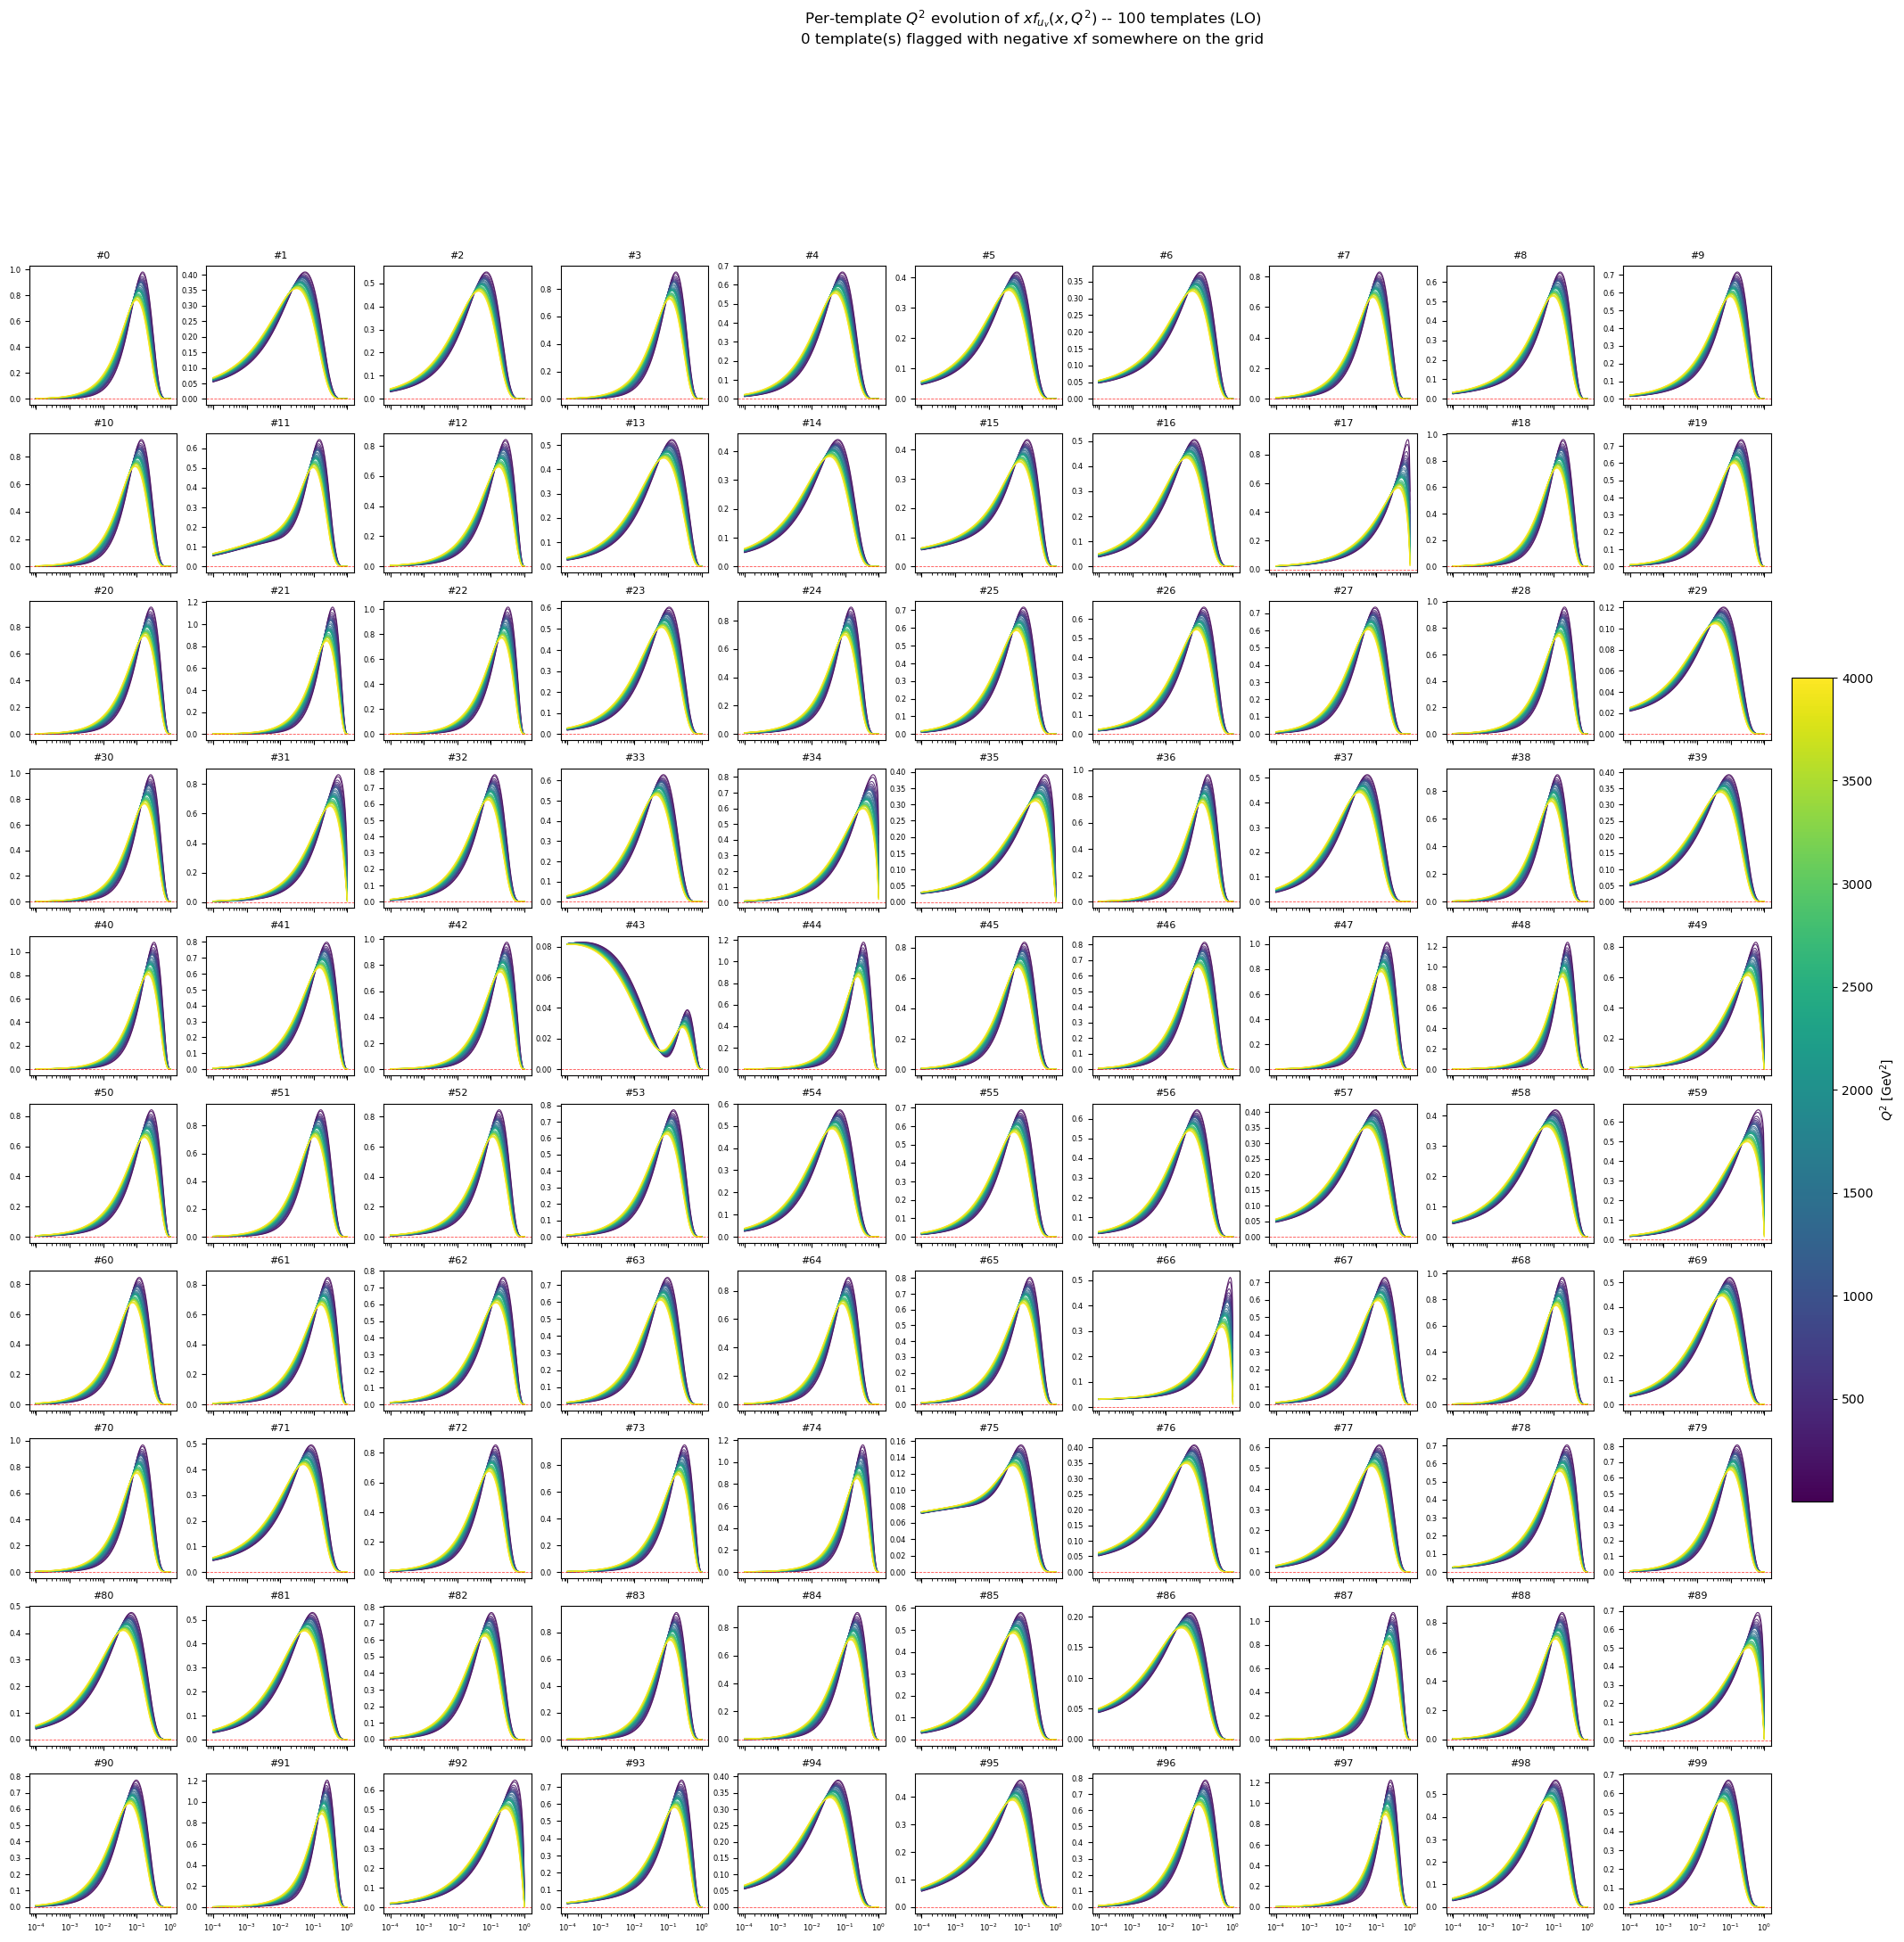

saved uv1_data/jam2pythia_uv1_scan/pickles/uv1_scan_results_per_template_evolution.png
no templates show negative xf on this grid -- all curves stay positive


In [21]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

PICKLE_GLOB = "uv1_scan_results.pkl"


def plot_all_curves(pickle_path):
    with open(pickle_path, "rb") as f:
        dataset = pickle.load(f)

    x_grid = dataset["x_grid"]
    q2_grid = dataset["q2_grid"]
    xu = dataset["xu"]                 # (n_var, n_q2, n_x) -- xf_uv(x, Q^2)
    n_var, n_q2, n_x = xu.shape
    order = dataset["metadata"].get("order", "?")

    # One subplot per template; each subplot overlays that template's curve
    # across all 32 Q^2 values, colored by Q^2. This isolates evolution
    # (curves within a panel) from template-to-template shape variation
    # (panel to panel), and a red dashed zero-line makes any negative-xf
    # excursion easy to spot by eye.
    cmap = plt.get_cmap("viridis")
    q2_colors = cmap(np.linspace(0, 1, n_q2))

    n_cols = 10
    n_rows = int(np.ceil(n_var / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(3 * n_cols, 2.4 * n_rows), sharex=True
    )
    axes = np.atleast_1d(axes).flatten()

    negative_templates = []
    for i in range(n_var):
        ax = axes[i]
        for j in range(n_q2):
            ax.plot(x_grid, xu[i, j, :], color=q2_colors[j], lw=0.8, alpha=0.85)

        is_negative = bool(xu[i].min() < 0)
        if is_negative:
            negative_templates.append(i)

        ax.axhline(0, color="red", lw=0.6, ls="--", alpha=0.7)
        ax.set_xscale("log")
        ax.set_title(f"#{i}" + (" ⚠" if is_negative else ""),
                     fontsize=8, color=("red" if is_negative else "black"))
        ax.tick_params(labelsize=6)

    for i in range(n_var, len(axes)):
        axes[i].axis("off")

    sm = cm.ScalarMappable(
        cmap=cmap, norm=plt.Normalize(vmin=q2_grid.min(), vmax=q2_grid.max())
    )
    sm.set_array([])
    fig.colorbar(sm, ax=list(axes[:n_var]), label="$Q^2$ [GeV$^2$]", pad=0.01, shrink=0.5)

    fig.suptitle(
        f"Per-template $Q^2$ evolution of $xf_{{u_v}}(x, Q^2)$ -- {n_var} templates ({order})\n"
        f"{len(negative_templates)} template(s) flagged with negative xf somewhere on the grid",
        y=1.0,
    )
    out_path = pickle_path.with_name(pickle_path.stem + "_per_template_evolution.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"saved {out_path}")
    if negative_templates:
        print(f"templates with negative xf somewhere on the grid: {negative_templates}")
    else:
        print("no templates show negative xf on this grid -- all curves stay positive")


pickle_files = sorted(DATA_OUTPUT.glob(PICKLE_GLOB))
if not pickle_files:
    print(f"no files matching {PICKLE_GLOB} found in {DATA_OUTPUT}")
for path in pickle_files:
    plot_all_curves(path)


In [22]:
# Inspect the [N, a, b, c, d] parameters for template 85, as it has an odd shape

TEMPLATE_IDX = 43  # CHANGE: index into uv1_variations / xu

row = uv1_variations[TEMPLATE_IDX]
param_names = ["N", "a", "b", "c", "d"]

print(f"template #{TEMPLATE_IDX} parameters:")
for name, val in zip(param_names, row):
    print(f"  {name} = {val:.4g}")

template #43 parameters:
  N = 0.32
  a = -0.9438
  b = 3.036
  c = -6.249
  d = 10.65
